**`Problem Statement`**

With thousands of titles available on Netflix, users often struggle to find content that matches their interests. Browsing manually can be time-consuming and inefficient.

👉 The challenge is to build a system that:

Understands movie/TV show content
Identifies similarities between titles
Recommends relevant content automatically

**Objective**

The main objective of this project is to:

***Build a content-based recommendation system using Netflix data
Convert textual information (description, genre) into numerical form
Measure similarity between titles using TF-IDF and cosine similarity
Recommend top similar movies/TV shows based on user input***


**Dataset**



👉 Netflix Movies and TV Shows Dataset (Kaggle)
https://www.kaggle.com/datasets/shivamb/netflix-shows

**Dataset Description**

The dataset contains information about Netflix titles such as:

1. Title

2.  Type (Movie / TV Show)
3.  Director
4. Cast
5. Country
6. Release Year
7. Rating
8. Duration
9. Genre (listed_in)
10. Description

**STEP 1: Import Libraries**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**STEP 2: Load the Dataset**

In [14]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

**Step 3:Store the Data in SQL**

In [15]:
import sqlite3

# Create database
conn = sqlite3.connect("netflix.db")

# Store data into SQL
df.to_sql("netflix", conn, if_exists="replace", index=False)

print("Data stored in SQL!")

Data stored in SQL!


**Query data using SQL**

In [16]:
query = """
SELECT title, description, listed_in
FROM netflix
WHERE type = 'Movie'
"""

df_sql = pd.read_sql(query, conn)

**Top genres**

In [17]:
query = """
SELECT listed_in, COUNT(*) as count
FROM netflix
GROUP BY listed_in
ORDER BY count DESC
LIMIT 5
"""

top_genres = pd.read_sql(query, conn)
print(top_genres)

                                          listed_in  count
0                      Dramas, International Movies    362
1                                     Documentaries    359
2                                   Stand-Up Comedy    334
3            Comedies, Dramas, International Movies    274
4  Dramas, Independent Movies, International Movies    252


**Movies vs TV **

In [18]:
query = """
SELECT type, COUNT(*) as total
FROM netflix
GROUP BY type
"""

print(pd.read_sql(query, conn))

      type  total
0    Movie   6131
1  TV Show   2676


**Although the recommendation model (TF-IDF + cosine similarity) is implemented in Python, SQL is used as a data management and querying layer to make the project more realistic and scalable.**
**“SQL was used to store, manage, and query the dataset efficiently before feeding it into the machine learning pipeline, thereby simulating a real-world data workflow and improving data handling capabilities.”**

**STEP 4: Data PreProcessing**

In [19]:
print(df.head())
print(df.shape)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

**1.Loads your dataset into a DataFrame

2.head() → shows first 5 rows

3.shape → tells rows & columns**



**STEP 5: Data Cleaning**

In [20]:
df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'Unknown',
    'rating': 'Not Rated',
    'description': ''
}, inplace=True)

Real-world data has missing values ❌
ML models cannot handle missing data → we replace them

**STEP 6: Convert Date Column**

In [21]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

Converting text to proper date format for further analaysis
Needed for extracting year/month separately

**STEP 7: Feature Engineering**

In [22]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

ML models understand numbers better than raw dates
We need extract useful features such as year ,month  from date _added attribute using df['date_added'].dt.year

**STEP 8: Select Important Columns**

In [23]:
df_ml = df[['type', 'title', 'description', 'listed_in']].copy()

it is better to keep useful columns in an df_ml data frame
type → target (Movie / TV Show)
others → input features

**STEP 9: Combine Text Features**

In [24]:
df_ml['text'] = df_ml['title'] + " " + df_ml['description'] + " " + df_ml['listed_in']

combining all text input as one for better performance
ML model needs one input column
So we combine all text into one

**STEP 10: Convert Target to Numbers**

In [25]:
df_ml['type'] = df_ml['type'].map({'Movie': 0, 'TV Show': 1})

ML models don’t understand text labels
So Encoding the variable is mandatory for text processing

**Movie → 0**

**TV Show → 1**

**STEP 11: Remove Missing Rows**

In [26]:
df_ml.dropna(inplace=True)

**Ensuring no null values  before training for better perfomance**

**STEP 12: Train-Test Split**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_ml['text'],
    df_ml['type'],
    test_size=0.2,
    random_state=42
)

**Split the dataset as 80 % Training and 20% Testing**

Train model on 80% data
Test on 20%
Ensures model generalization

**STEP 13: Convert Text → Numbers (TF-IDF)**

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

**ML models need numbers, not text**
***TF-IDF Vectorization***
converts Words to numbers
which Gives importance to meaningful words and skip stop words like an,the **

**STEP 14: Train Models**

In [29]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

Simple & effective classifier
Works well for text

**Naive Bayes**

In [30]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

MultinomialNB()

Perfoms better in Text classification


**STEP 15: Predictions**

In [31]:
lr_pred = lr_model.predict(X_test_vec)
nb_pred = nb_model.predict(X_test_vec)

Model predicts labels for unseen data

**STEP 16: Evaluation**

In [32]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Logistic Regression Accuracy: 0.981838819523269
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1214
           1       1.00      0.95      0.97       548

    accuracy                           0.98      1762
   macro avg       0.99      0.97      0.98      1762
weighted avg       0.98      0.98      0.98      1762

Naive Bayes Accuracy: 0.9580022701475596
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1214
           1       1.00      0.87      0.93       548

    accuracy                           0.96      1762
   macro avg       0.97      0.93      0.95      1762
weighted avg       0.96      0.96      0.96      1762



Logistic Regression Accuracy → 98.18%
Naive Bayes Accuracy → 95.80%

👉 This means:

Logistic Regression predicts correctly ~98 out of 100 times
Naive Bayes predicts correctly ~96 out of 100 times

✔️ So overall, Logistic Regression performs better

Logistic Regression outperforms Naive Bayes in this dataset with higher accuracy and better recall for the positive class. While both models achieve perfect precision for class 1, Naive Bayes fails to capture more actual positive cases, making Logistic Regression more reliable for this problem.

**STEP 17:Confusion Matrix**

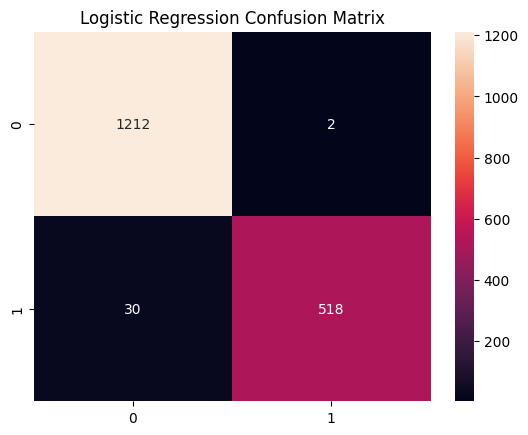

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

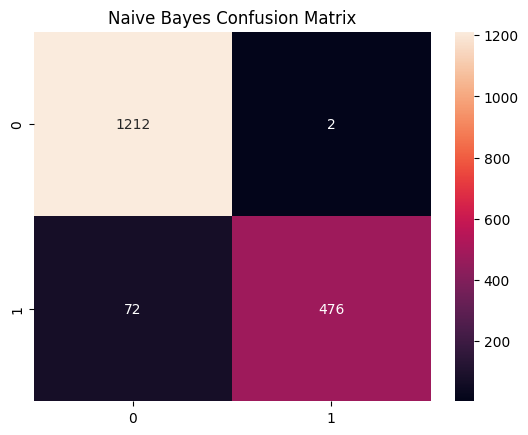

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Naive Bayes performs well in identifying negative cases, but it misses a higher number of positive cases (72 false negatives), making it less reliable than Logistic Regression for detecting important positive instances.

The model performs very well with high correct predictions, but it slightly struggles in identifying some positive cases (30 false negatives), which could be important depending on the application.

**Netflix Movie Recommendation using Cosine Similarity**

In [35]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Fill missing values
df['description'] = df['description'].fillna('')
df['listed_in'] = df['listed_in'].fillna('')

# Combine features
df['content'] = df['description'] + " " + df['listed_in']

# Convert text to numbers
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['content'])

# Compute similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Create index mapping
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

# Recommendation function
def recommend(title, num_recommendations=10):
    if title not in indices:
        return "Title not found"

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top results (excluding itself)
    sim_scores = sim_scores[1:num_recommendations+1]

    movie_indices = [i[0] for i in sim_scores]

    return df['title'].iloc[movie_indices]

# Test
recommendations = recommend("Narcos")

print("Top Recommendations:\n")
for i, title in enumerate(recommendations, 1):
    print(f"{i}. {title}")

Top Recommendations:

1. Miss Dynamite
2. Narcos: Mexico
3. El Cartel 2
4. El Chapo
5. Ganglands
6. El final del paraíso
7. Cocaine Cowboys: The Kings of Miami
8. Historia de un clan
9. Sin senos no hay paraíso
10. Top Boy


**“Here cosine similarity is used to  movie index to retrieve its similarity scores from the cosine similarity matrix and then selected the top similar indices to generate recommendations.”**

**“The system outputs the most similar titles based on cosine similarity scores. The index values represent dataset rows, and the titles are the recommended content.”**

In [39]:
import plotly.express as px

def recommend_with_scores(title, num=5):
    if title not in indices:
        return None

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Skip itself
    sim_scores = sim_scores[1:num+1]

    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]

    result_df = pd.DataFrame({
        "Title": df['title'].iloc[movie_indices].values,
        "Similarity Score": scores
    })

    return result_df

In [42]:
title = "Narcos"

result = recommend_with_scores(title)

fig = px.bar(
    result,
    x="Similarity Score",
    y="Title",
    orientation='h',
    title=f"Top Recommendations for {title}"
)

fig.show()

In [43]:
fig = px.bar(
    result,
    x="Similarity Score",
    y="Title",
    orientation='h',
    title=f"Top Recommendations for {title}",
    color="Title",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.show()